In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
import pandas as pd

column_names = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

df = pd.read_csv(
    "auto-mpg.data",
    delim_whitespace=True,
    names=column_names,
    na_values="?"
)

df.to_csv("auto-mpg.csv", index=False)

print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year  origin                   car_name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  


In [17]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB
None
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


In [19]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

df = df.dropna()

print(df.shape)

(392, 9)


In [21]:
X = df[['displacement']]
y = df['mpg']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MSE :", mse_linear)
print("R² :", r2_linear)

Linear Regression
MSE : 21.227484289611397
R² : 0.5841057656051312


In [35]:
poly3 = PolynomialFeatures(degree=3)

X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

poly_model3 = LinearRegression()

poly_model3.fit(X_train_poly3, y_train)

y_pred_poly3 = poly_model3.predict(X_test_poly3)

mse_poly3 = mean_squared_error(y_test, y_pred_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)

print("Polynomial Degree 3")
print("MSE :", mse_poly3)
print("R² :", r2_poly3)poly3 = PolynomialFeatures(degree=3)

X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

poly_model3 = LinearRegression()

poly_model3.fit(X_train_poly3, y_train)

y_pred_poly3 = poly_model3.predict(X_test_poly3)

mse_poly3 = mean_squared_error(y_test, y_pred_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)

print("Polynomial Degree 3")
print("MSE:", mse_poly3)
print("R²:", r2_poly3)

Polynomial Degree 3
MSE : 20.81794078857357
R² : 0.5921296453306659


/home/netlab/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/netlab/.local/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


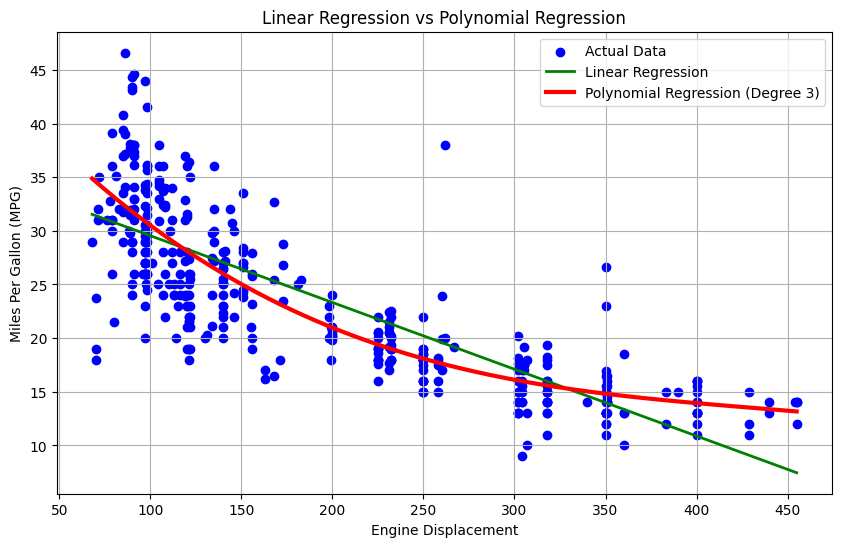

In [36]:
# Create smooth X values for plotting
X_plot = np.linspace(X.min().values[0], X.max().values[0], 300).reshape(-1, 1)

# Linear Regression predictions
y_linear = linear_model.predict(X_plot)

# Polynomial Regression predictions (Degree 3)
X_plot_poly = poly3.transform(X_plot)
y_poly = poly_model3.predict(X_plot_poly)

# Plot
plt.figure(figsize=(10,6))

# Actual data
plt.scatter(X, y, color='blue', label='Actual Data')

# Linear Regression line
plt.plot(X_plot, y_linear,
         color='green',
         linewidth=2,
         label='Linear Regression')

# Polynomial Regression curve
plt.plot(X_plot, y_poly,
         color='red',
         linewidth=3,
         label='Polynomial Regression (Degree 3)')

plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")
plt.title("Linear Regression vs Polynomial Regression")

plt.legend()
plt.grid(True)

plt.show()